# Build Features from Waveform

In [1]:
from bioacoustics.data import load_metadata, load_audio, save_results

from bioacoustics.features import (
    get_features,
    get_spectrogram,
    prepare_data,
    get_mel_spectrogram,
    get_mfcc,
    get_chroma_stft,
)

from bioacoustics.visualization import (
    plot_spectrogram,
    plot_waveform,
    plot_cepstrum_pipeline,
    plot_mfcc,
    plot_chroma_stft,
)

%load_ext autoreload
%autoreload 2

## Load metadata and example audio

In [2]:
df_train, df_train_soundscapes, df_taxonomy = load_metadata()
example_audio = load_audio(df_train_soundscapes.iloc[0])
# example_audio = load_audio(df_train.iloc[0])

## Get features

Features that can be extracted from sound:
- raw signal features:
    - mean, variance
    - zero-crossing rate
- frequency based:
    - spectral features
        - spectral centroid
        - spectral bandwidth
        - spectral rolloff ?
    - MFCC: Mel_Frequency Cepstral Coefficients ...
- time-frequency features:
    - spectrogram stats
    - chroma features

think about how can we detect repeated patterns in spectrogram (in a sense oscillation of oscillations...) - is there a kinda 3D spectrogram for that - e.g. do a FT on the spectrogram... is there a smarter way to do it?

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

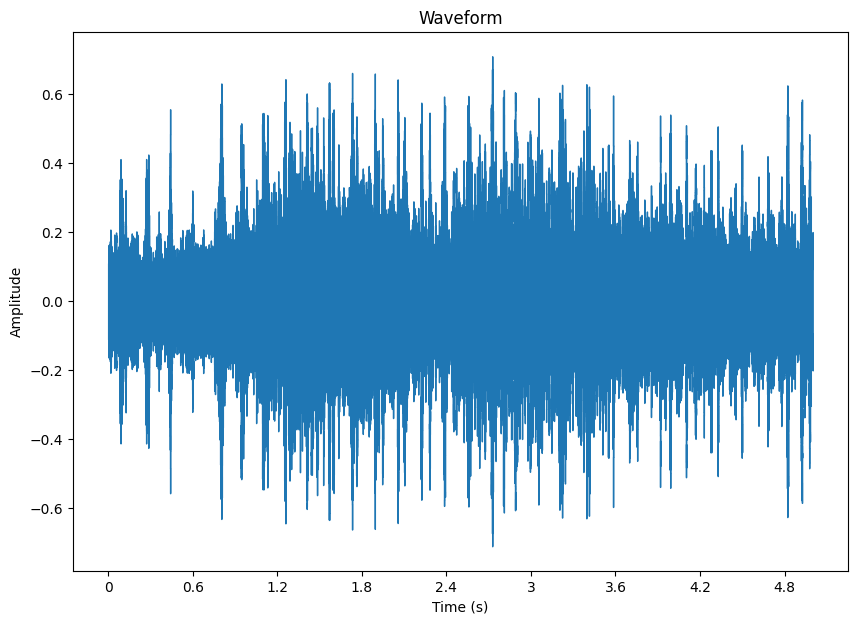

In [4]:
plot_waveform(example_audio)
plt.show()

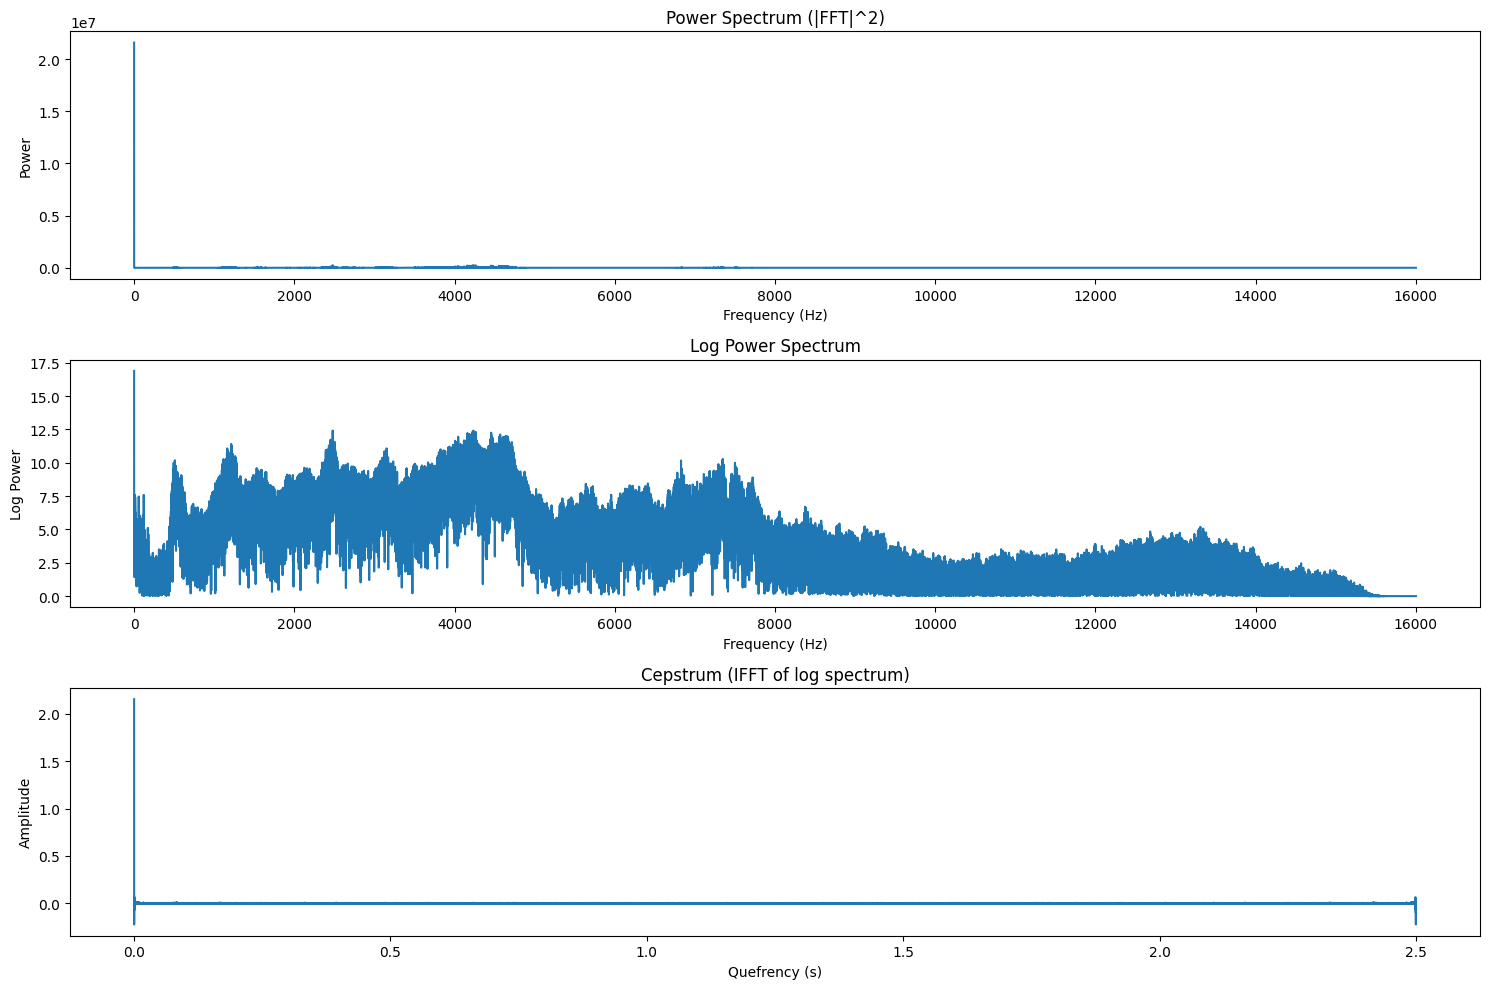

In [5]:
plot_cepstrum_pipeline(example_audio)

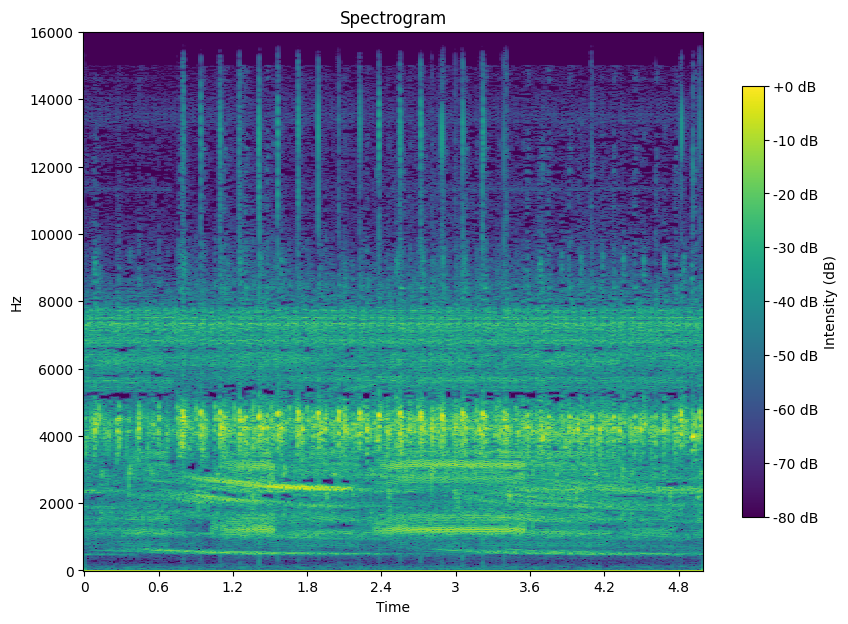

In [6]:
S_db, frequencies, times = get_spectrogram(example_audio)
plot_spectrogram(S_db)
plt.show()

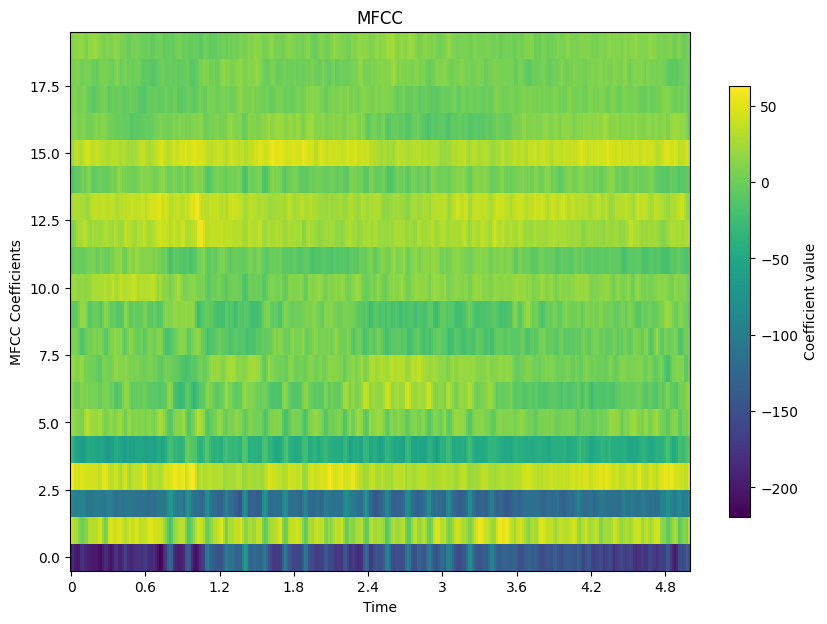

In [7]:
mfccs = get_mfcc(example_audio)
plot_mfcc(mfccs)
plt.show()

**TODO:** visualize log mel, chroma ...

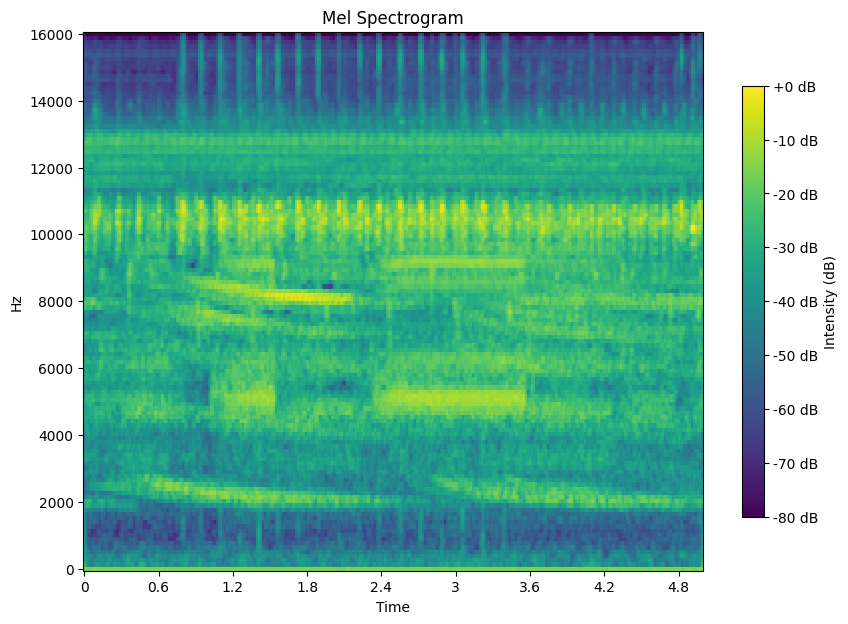

In [8]:
S_db, frequencies, times = get_mel_spectrogram(example_audio)
plot_spectrogram(S_db, title="Mel Spectrogram")
plt.show()

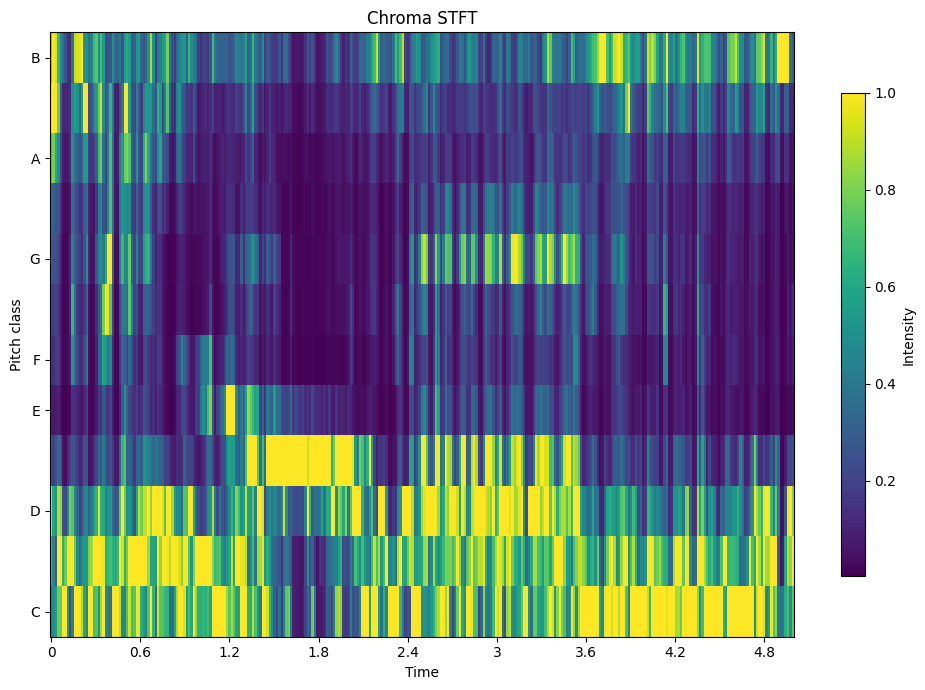

In [9]:
chroma_stft = get_chroma_stft(example_audio)
plot_chroma_stft(chroma_stft)
plt.show()

Allegedly (According to ChatGPT) using chroma is not good for our purposes.

### Example of all features collected for an audio:

In [10]:
get_features(example_audio)

mean               0.029033
std                0.115452
max                0.710078
min               -0.657333
rms                0.119046
                     ...   
mel_band_19_std    8.477489
rms_frame_mean     0.114133
rms_frame_std      0.033202
rms_frame_max      0.188637
rms_frame_min      0.043595
Length: 187, dtype: float64

## Put together features and labels

In [11]:
NB_EXAMPLES = 500  # ~ 250 samples / min
np.random.seed(42)
data_train = prepare_data(
    df_train, df_taxonomy, sample_idx=np.random.randint(0, len(df_train), NB_EXAMPLES)
)
data_train_soundscapes = prepare_data(
    df_train_soundscapes,
    df_taxonomy,
    sample_idx=np.random.randint(0, len(df_train_soundscapes), NB_EXAMPLES),
)

Extracting features:   0%|          | 0/500 [00:00<?, ?it/s]

/Users/milosoundjian/Documents/sorbonne/bioacoustic-species-detection/.venv/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Extracting features:   0%|          | 0/500 [00:00<?, ?it/s]

/Users/milosoundjian/Documents/sorbonne/bioacoustic-species-detection/.venv/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


## Save results

In [12]:
save_results(data_train, "features", "data_train")
save_results(data_train_soundscapes, "features", "data_train_soundscapes")